# FEATURE ENGINEERING

## Load the data
- Here I load the pickle file that was saved in step1

In [17]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# We load the pickle file so we have the correct data type

df = pd.read_pickle('data_MPG_clean.pkl')

In [19]:
# print 10 sample values

print(df.sample(10))

           mpg  cylinders  displacement  horsepower  weight  acceleration  \
262  19.203125          8           305         145    3425     13.203125   
188  16.000000          8           318         150    4190     13.000000   
237  30.500000          4            98          63    2051     17.000000   
171  24.000000          4           134          96    2702     13.500000   
336  23.593750          4           140         104    2905     14.296875   
102  26.000000          4            97          46    1950     21.000000   
47   19.000000          6           250         100    3282     15.000000   
59   23.000000          4            97          54    2254     23.500000   
377  31.000000          4            91          68    1970     17.593750   
145  32.000000          4            83          61    2003     19.000000   

     model_year  origin  
262          78     usa  
188          76     usa  
237          77     usa  
171          75   japan  
336          80     us

In [20]:
# describe

print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  398.000000   398.000000   
mean    23.515625    5.454774    193.424623  104.462312  2970.424623   
std      7.816406    1.701004    104.271000   38.199230   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   76.000000  2223.750000   
50%     23.000000    4.000000    148.500000   95.000000  2803.500000   
75%     29.000000    8.000000    262.000000  125.000000  3608.000000   
max     46.593750    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.570312   76.010050  
std        2.757812    3.697627  
min        8.000000   70.000000  
25%       13.822266   73.000000  
50%       15.500000   76.000000  
75%       17.175781   79.000000  
max       24.796875   82.000000  


In [21]:
# lets see data types and memory usage

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           398 non-null    float16 
 1   cylinders     398 non-null    uint8   
 2   displacement  398 non-null    int16   
 3   horsepower    398 non-null    uint8   
 4   weight        398 non-null    int16   
 5   acceleration  398 non-null    float16 
 6   model_year    398 non-null    int8    
 7   origin        398 non-null    category
dtypes: category(1), float16(2), int16(2), int8(1), uint8(2)
memory usage: 5.0 KB
None


# Derived Feature: Power-to-Weight Ratio

Instead of raw horsepower and weight, we combine them.

In [22]:
df['power_to_weight'] = df['horsepower'] / df['weight']
print(df[['horsepower', 'weight', 'power_to_weight']].head())

# We can drop HP and weight.

   horsepower  weight  power_to_weight
0         130    3504         0.037100
1         165    3693         0.044679
2         150    3436         0.043655
3         150    3433         0.043694
4         140    3449         0.040591


# Weight Categories (Binning)
- Here weight range from 1613 to 5140


### Define bins:
-  light : 0 - 2000
-  medium: 2000 - 3000
-  heavy: 3000 - 5200

In [23]:
# step1: 
weight_bins = [0, 2000, 3000, 5200]
weight_labels = ['light', 'medium', 'heavy']

df['weight_category'] = pd.cut(
    df['weight'],
    bins=weight_bins,
    labels=weight_labels
)


# display 10 sample values
print(df[['weight', 'weight_category']].sample(10))

     weight weight_category
236    2755          medium
212    4380           heavy
358    2635          medium
354    2320          medium
17     2587          medium
257    3210           heavy
355    2210          medium
67     4633           heavy
388    2585          medium
367    2605          medium


In [24]:
# stpe2: Distribution Check

df['weight_category'].value_counts()

weight_category
medium    186
heavy     168
light      44
Name: count, dtype: int64

In [25]:
# step3: Display mean MPG by Weight Category

df.groupby('weight_category', observed=True)['mpg'].mean()

# observ: MPG decreases as we move from light → heavy
# Binning reveals trends clearly

weight_category
light     33.158024
medium    27.253864
heavy     16.848866
Name: mpg, dtype: float32

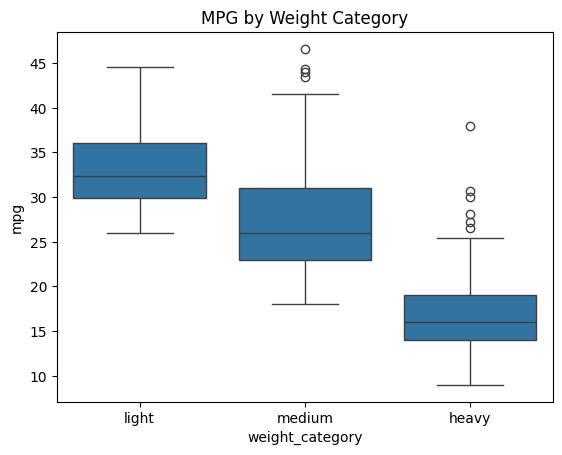

In [26]:
# step4:  Visualization of Binned Features (Weight Category vs MPG)
sns.boxplot(
    data=df,
    x="weight_category",
    y="mpg",
    order=['light', 'medium', 'heavy']
)

plt.title("MPG by Weight Category")
plt.show()


# Horsepower Bins (Quantile-Based Binning)
- **Equal-frequency bins** are often better than fixed bins.

In [27]:
# step1: 
df['horsepower_bin'] = pd.qcut(
    df['horsepower'],
    q=3,
    labels=['low', 'medium', 'high']
)

df[['horsepower', 'horsepower_bin']].sample(10)


,horsepower,horsepower_bin
348,62,low
372,90,medium
78,87,medium
335,88,medium
31,95,medium
378,63,low
69,160,high
248,60,low
14,95,medium
257,90,medium


In [28]:
# step2: display value counts

df['horsepower_bin'].value_counts()

horsepower_bin
low       141
medium    141
high      116
Name: count, dtype: int64

In [29]:
# step3: Display avg MPG by horsepower_bin

df.groupby('horsepower_bin', observed=True)['mpg'].mean()

horsepower_bin
low       30.662899
medium    22.730608
high      15.778421
Name: mpg, dtype: float32

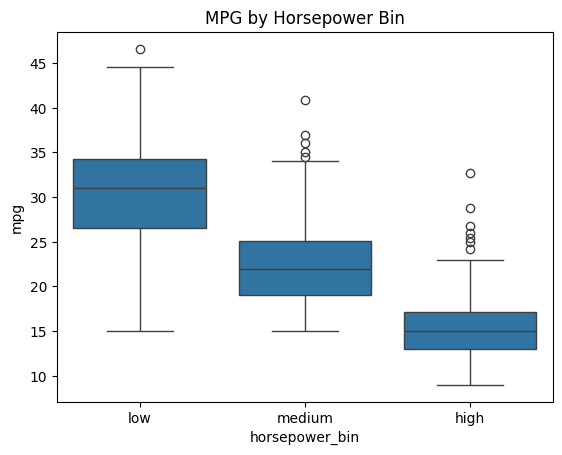

In [30]:
# step4
sns.boxplot(
    data=df,
    x="horsepower_bin",
    y="mpg",
    order=['low', 'medium', 'high']
)

plt.title("MPG by Horsepower Bin")
plt.show()


## Age of Car (Temporal Feature)
- Concept: Time-based feature engineering
- 

In [31]:
df["car_age"] = df["model_year"].max() - df["model_year"]
df[["model_year", "car_age"]].head()

,model_year,car_age
0,70,12
1,70,12
2,70,12
3,70,12
4,70,12
